# Task 3 — Final Evaluation and Ultimate Judgement

The development study produced two fixed recipes through different paths. Gender progressed
through pooling, label review and regularisation to SAM25. Usage progressed through class
weighting and translation to E8, while additional retail images failed to solve its rare-class
problem. Final evaluation examines how those development conclusions hold up in the saved
reserved-image comparisons and what the remaining errors imply for use.

The accepted artifacts are the single Gender SAM25 refit and single teacher-only Usage E8
refit. The account first establishes their evaluation conditions, then compares aggregate
results, class errors, uncertainty and measured costs. Separate Gender and Usage judgements
connect that evidence to the proposed catalogue workflow.

**Run All** reads saved model records and rebuilds tables and figures. No training or new
holdout inference runs here. Model-choice reasoning comes from the development study;
the saved holdout results provide the final assessment. Sections 1–8 preserve that
evaluation contract, Sections 9–10 present the evidence, Sections 11–12 give the judgements,
and Section 13 records the handoff. Sections 14–15 relate the remaining failures to research
and set out future improvements; Section 16 lists the references.


## 1. Task 3 evaluation contract

The first requirement was a consistent evaluation population. Both refits used only development
rows from `data/processed/splits.csv`; official prediction images remained separate from the
internal holdout. The following analysis reads saved predictions and scores without further
tuning, training or inference.

The development notebook explains the retained recipes and their trade-offs. This notebook
assesses their saved predictions and practical limits; it does not rank recipes for a new
training run or choose a different checkpoint. Replaying saved results is not a new blind evaluation.


## 2. Frozen inputs from task notebooks

**Gender entered the comparison as a fixed SAM25 refit:** the accepted model is one scratch SAM25 refit trained for 25 epochs.
The saved model identity and preprocessing are displayed by code in Section 13.
Its primary holdout metric is five-class macro-F1 on original labels, with accuracy alongside it.
The 79.73% corrected-label development OOF score belongs to the earlier fold models.


**Usage entered the comparison as a fixed E8 refit:** the accepted model is one teacher-only E8 refit trained for 30 epochs.
Section 13 displays its saved identity and preprocessing alongside Gender.
Its primary score is nine-class macro-F1, including zero for absent Home; accuracy is reported
alongside it. The 41.94% development OOF score belongs to the earlier E8 fold models.

These fixed inputs separate evidence about the earlier fold models from evidence about the
new checkpoints. The subsequent records preserve that distinction through acceptance and scoring.


## 3. Identify the selected runs and fixed recipes

**Gender model:** the completed single SAM25 refit, with the earlier average retained as a
comparison. The development notebook explains the recipe and reproduces the registered refit row.
The exact run and checkpoint are verified in Section 9.3 below.

**Usage model:** the completed single E8 refit. Its development trade-offs combine class
coverage, shift tolerance and probability quality with accuracy, lighting and uncertainty
costs. E1 remains the accuracy alternative. The development notebook preserves that
reasoning and both refit records; Section 9.5 assesses their saved holdout predictions.


## 4. Confirm metric and CV evidence

The recipes entered this evaluation with five-fold development evidence. Their OOF scores
pool predictions made on each held-out fold before calculating macro-F1. That establishes
evidence about the recipes, while the later refits require their own evaluation because all
development rows participated in training.

Gender's corrected-label development score and original-label holdout score also use different
reference labels. Their difference cannot be read as a direct generalisation gap. Both refits
use one seed; repeated development comparisons and later holdout review limit the independence
of the final model choice.


## 5. Refit on all development

The completed runs were recorded through `results/runs.csv`. The saved registry snapshots
below preserve those run records; this evaluation notebook does not change the registry.

**Gender refit record:** 32,773 development rows, fresh scratch weights, seed 2753, 25 fixed epochs,
no validation or early stopping. The completed registered run is preserved in
`reports/task3/gender_final_sam25_refit_20260907/refit_runs.csv`. Its OOF score is undefined:
all development rows participated in training. The holdout scores below are separate evidence.

**Usage refit record:** E1 and E8 each trained from scratch on 32,772 eligible development rows,
seed 2753, for 30 fixed epochs without validation or early stopping. E8 is the accepted artifact.
Their completed registry records are preserved in
`reports/task3/usage_final_e8_refit_20260907/refit_runs.csv`.
Notebook 4 reads these saved rows and plots training behaviour; this notebook does not train.

The completed fits supplied new checkpoints, but their training records could establish only
completion and cost. The evaluation therefore retained a separate record of preprocessing and
reserved-image predictions for each model.


## 6. Fit final preprocessing on all development

**Gender preprocessing:** normalization was fitted to full-development content pixels, excluding
padding. The acceptance manifest records its hash and training-row digest. Evaluation applies
those saved RGB statistics to 80×60 content pixels, with zero padding and evaluation mode;
no statistics are fitted on holdout images.

**Usage preprocessing:** each refit has its own saved full-development content-pixel normalization.
E8 also fitted class weights from development labels for training. Its manifest records the
preprocessing and configuration. Evaluation reuses those statistics without fitting them
again or adjusting prediction probabilities.

Saving these transformations with each checkpoint made the later comparison reproducible
and kept information from reserved images out of the learned preprocessing.


## 7. Lock final checkpoints and outputs

**Gender lock:** the accepted checkpoint SHA-256 is
`41a5f5ea027805e8edbbf667d080564776ca9873d9146e0dec15c0d4bec2b272`.
The original training receipt and earlier five-model manifest retain their exact bytes.
The model manifest identifies the exact artifact assessed below. Its settings and saved
preprocessing are applied unchanged during evaluation.

**Usage lock:** the accepted E8 manifest pins the checkpoint and configuration hashes.
The original run receipts remain the training record. Evaluation uses that fixed artifact;
the holdout results do not select a new epoch, augmentation policy or probability adjustment.


## 8. Open internal holdout once

**Gender is already evaluated:** the authorized refit scoring pass is recorded separately in
`reports/task3/gender_sam25_refit_holdout_20260907/evaluate.py` and `evaluation.json`.
The script uses the protected loader with `evaluation_unlocked=True`, after saving predictions.
This notebook reads the saved evidence; it does not repeat the loader call or run inference.

**Usage is already evaluated:** the saved E1/E8 comparison and scoring record are in
`reports/task3/usage_e8_refit_holdout_20260907/`. Section 9.5 reads these results and checks their
sources. The holdout had already been reviewed; reproducing saved tables does not reopen it.

The numerical analysis begins from those completed records. Its purpose is to explain the
observed choices and remaining errors using a consistent basis throughout.


## 9. Reserved holdout evaluation and independence limits

With the model identities and evaluation conditions established, the saved comparisons can
address the claims carried forward from development. Gender is compared with its earlier
five-model average. Usage is compared with both the historical alternatives and the matched
E1 refit, preserving the distinction between recipe choice and the effect of refitting.


### 9.1 Task 3: scope of the completed holdout evaluation

The following cells reproduce **saved results**, not a new opening of protected data. Both targets
were scored on the same 5,778 reserved teacher images. The saved audits report no overlap of
holdout IDs or saved product families with development and verify the input image hashes.
Original labels came from teacher training metadata, joined by product ID; every row was scored.

The accepted models are the single full-development Gender SAM25 refit and the single
teacher-only E8 Usage refit. Earlier five-model averages remain historical comparisons.
These cells do not refit preprocessing, load
weights, run inference or change the registry.

**Scope of the evidence.** Saved prediction and scoring records identify the artifacts
under comparison. This notebook reports their measured behaviour, rather than treating
the holdout as another tuning fold. These results must not guide future changes to the
recipe, checkpoint or preprocessing; those changes need a separate development study.

The following code reads saved evaluation records, comparison tables and class counts.
It displays the evidence directly and checks that it belongs to the accepted checkpoints.
The teacher test set is prediction-only. No test scores are reported in this notebook.


### 9.2 Load tools

Import the tools used to read the saved tables and draw the figures.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

### 9.3 Gender: accepted single refit versus the earlier average

The Gender study retained SAM25 after its label and regularisation comparisons. The remaining
choice concerned the prediction artifact: one full-development model or the earlier five-model
average. Both systems are evaluated on the same images and original labels below.

The earlier average combines five softmax probability vectors equally before selecting a
class. The refit uses one checkpoint and its own full-development normalization. The code
checks their saved identities and then compares the resulting predictions.


In [2]:
EVAL_ROOT = next(
    p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "src/fashion").is_dir()
)
sys.path.insert(0, str(EVAL_ROOT / "src"))
from fashion.task3_gender_final import (  # noqa: E402 — project path set above
    verify_gender_final,
    verify_gender_holdout_sources,
)

gender_final = verify_gender_final(EVAL_ROOT)
gender_holdout_lock = verify_gender_holdout_sources(EVAL_ROOT)
GENDER_HOLDOUT = EVAL_ROOT / "reports/task3/gender_sam25_refit_holdout_20260907"
gender_evaluation = json.loads((GENDER_HOLDOUT / "evaluation.json").read_text())
assert gender_evaluation["run_id"] == gender_final["run_id"]
assert gender_evaluation["checkpoint_sha256"] == gender_final["checkpoint"]["sha256"]
gender_holdout = pd.read_csv(GENDER_HOLDOUT / "holdout_comparison.csv", keep_default_na=False)
gender_primary = gender_holdout.loc[gender_holdout.labels.eq("Original labels")].set_index("model")
gender_table = gender_primary[["images", "accuracy", "macro_f1", "ece_15"]].copy()
gender_table.insert(
    1,
    "Correct",
    [
        int(np.trace(gender_evaluation["metrics"][f"Original labels: {name}"]["confusion_matrix"]))
        for name in gender_table.index
    ],
)
gender_table[["accuracy", "macro_f1", "ece_15"]] *= 100
display(
    gender_table.rename(
        index={"Single refit": "Single refit · FINAL"},
        columns={
            "images": "Images",
            "accuracy": "Accuracy (%)",
            "macro_f1": "Macro-F1 (%)",
            "ece_15": "Calibration error (%)",
        },
    ).round(2)
)

,Images,Correct,Accuracy (%),Macro-F1 (%),Calibration error (%)
model,,,,,
Five-model average,5778,5190,89.82,77.14,2.35
Single refit · FINAL,5778,5200,90.00,77.44,2.37


**Result.** The accepted refit gets **5,200/5,778** images right: **90.00% accuracy and
77.44% macro-F1** against the original labels. The earlier average gets 5,190 right, with
89.82% accuracy and 77.14% macro-F1. The gains are **0.17 accuracy points and 0.30 F1 points**.
The refit fixes **65** earlier errors but creates **55** new errors; **523** are wrong under both.
Ten net correct images is a small observed advantage, not proof of a stable gain across seeds.

The refit uses all development rows and one checkpoint. That supports the simpler final handoff,
but it does not establish that every class improved. Macro-F1 gives each class equal weight;
the class analysis below shows the remaining mistakes and recall trade-offs.

Earlier original-label OOF F1 was 75.33%; corrected-label OOF F1 was 79.73%. These belong to the
fold models, each trained on four development folds. The refit uses five folds for training and
a different population for evaluation. Its holdout–OOF difference cannot be attributed to
generalisation alone or presented as a new development validation score.


#### Separate fixed name-rule diagnostic

The development label review made the scoring basis part of the interpretation. Applying the
existing name rule to the same saved holdout predictions measures that scoring effect separately;
the original-label result remains the primary comparison.


In [3]:
gender_diagnostic = gender_holdout.loc[
    gender_holdout.labels.eq("Fixed name-rule diagnostic")
].set_index("model")
display(
    gender_diagnostic[["accuracy", "macro_f1"]]
    .mul(100)
    .rename(
        index={"Single refit": "Single refit · FINAL"},
        columns={"accuracy": "Diagnostic accuracy (%)", "macro_f1": "Diagnostic F1 (%)"},
    )
    .round(2)
)

,Diagnostic accuracy (%),Diagnostic F1 (%)
model,,
Five-model average,90.41,80.45
Single refit · FINAL,90.57,80.78


The fixed rule changes 45 holdout labels. It gives the refit **90.57% accuracy / 80.78% F1**,
against **90.41% / 80.45%** for the earlier average. For the refit, the 3.35-point rise from
77.44% to 80.78% is a scoring-basis effect. It is not a gain learned from holdout images,
and it must not replace the original-label primary score.

This diagnostic reinforces the distinction made during development: better agreement with
a revised reference rule and better predictions under the original task are separate findings.


### 9.4 Usage: earlier five-model comparisons

Usage entered final evaluation with a trade-off between overall accuracy and rare-class
coverage. The historical E1, E8 and expanded-E8 results show where that trade-off first
appeared on the reserved images, before considering the later single-model refits.


In [4]:
usage_holdout = pd.read_csv(
    EVAL_ROOT / "reports/task3/usage_holdout_20260906/holdout_summary.csv", keep_default_na=False
)

usage_names = {"E1": "E1 · baseline", "E8": "E8 · translation", "Expanded": "E8 +120 images"}
usage_table = usage_holdout.set_index("model")[
    [
        "scored_images",
        "correct",
        "incorrect",
        "accuracy",
        "macro_f1_nine_classes",
        "macro_f1_classes_present",
    ]
].copy()
usage_table[["accuracy", "macro_f1_nine_classes", "macro_f1_classes_present"]] *= 100
display(
    usage_table.rename(
        index=usage_names,
        columns={
            "scored_images": "Images",
            "correct": "Correct",
            "incorrect": "Wrong",
            "accuracy": "Accuracy (%)",
            "macro_f1_nine_classes": "Nine-class F1 (%)",
            "macro_f1_classes_present": "Eight present classes · diagnostic F1 (%)",
        },
    ).round(2)
)

,Images,Correct,Wrong,Accuracy (%),Nine-class F1 (%),Eight present classes · diagnostic F1 (%)
model,,,,,,
E1 · baseline,5778,5192,586,89.86,36.39,40.93
E8 · translation,5778,5149,629,89.11,37.59,42.29
E8 +120 images,5778,5154,624,89.20,39.48,44.42


**Result.** E1 gets **5,192/5,778** right: **89.86% accuracy and 36.39% nine-class macro-F1**.
Original E8 gets 5,149 right; E8 with 120 added images gets 5,154. Thus E1 has 43 and 38 more
correct predictions respectively. The expanded model has the best macro-F1 here, 39.48%, so an
accuracy preference accepts a cost in equal-class performance. These are recorded comparisons;
they do not establish that E1 is best under every objective. No 687-image holdout result is available.

Against original E8, adding 120 images fixes 70 errors but creates 65: just five net correct images.
Its 1.89-point macro-F1 gain includes about 1.59 points from a single newly correct NA example.
That is a useful class-specific change, but the tiny support does not establish a stable overall
benefit from adding data. The class breakdown below makes this sensitivity visible.

Home has no holdout examples. The fixed nine-class F1 convention assigns it zero; the separately
labelled eight-present-class values are diagnostics, not substitutes for the main comparison.
An absent class cannot be assessed for recall on this set.

### 9.5 Usage: full-development E1 and E8 refits

The historical comparison left E1 as the accuracy alternative and did not establish reliable
rare-class recognition through expansion. The next comparison places E1 and E8 on the same
refit basis: 30 epochs on 32,772 eligible teacher development images, followed by evaluation
on the same **5,778 reserved teacher images**.

Each run has its own full-development normalization. The following code verifies the saved
labels and image IDs and reads the completed comparison; it does not load models or run
new inference.


In [5]:
import sys

sys.path.insert(0, str(EVAL_ROOT / "src"))
from fashion.task3_final import verify_usage_final, verify_usage_holdout_sources

usage_final = verify_usage_final(EVAL_ROOT)
usage_holdout_lock = verify_usage_holdout_sources(EVAL_ROOT)
REFIT_HOLDOUT = EVAL_ROOT / "reports/task3/usage_e8_refit_holdout_20260907"
refit_comparison = pd.read_csv(REFIT_HOLDOUT / "e1_e8_comparison.csv", keep_default_na=False)
assert refit_comparison.holdout_images.eq(5778).all()
refit_view = refit_comparison.set_index(["recipe", "model"]).drop(columns="holdout_images")
score_columns = ["accuracy", "macro_f1_nine_classes", "macro_f1_eight_present_classes"]
refit_view[score_columns] *= 100
display(
    refit_view.rename(
        columns={
            "accuracy": "Accuracy (%)",
            "correct": "Correct",
            "macro_f1_nine_classes": "Nine-class F1 (%)",
            "macro_f1_eight_present_classes": "Eight present · F1 (%)",
        }
    ).round(2)
)

Accuracy (%)  Nine-class F1 (%)  \
recipe model                                                 
E1     Five-model average         89.86              36.39   
       Single refit               89.46              36.09   
E8     Five-model average         89.11              37.59   
       Single refit               88.70              42.26   

                           Eight present · F1 (%)  Correct  
recipe model                                                
E1     Five-model average                   40.93     5192  
       Single refit                         40.60     5169  
E8     Five-model average                   42.29     5149  
       Single refit                         47.54     5125

**Result.** The E8 refit reaches **88.70% accuracy and 42.26% nine-class macro-F1**.
The E1 refit reaches **89.46% and 36.09%**. E8 gains **6.17 F1 points** and loses **0.76 accuracy
points**: 5,125 correct images versus 5,169. This is the accepted equal-class trade-off.

Refitting does not improve every metric. E1's refit loses 23 correct images and 0.30 F1 points
against its earlier average. E8's refit loses 24 correct images but gains 4.66 F1 points against
its earlier average. The earlier **41.94% E8 OOF score is development evidence**, not the old
holdout score; the old holdout macro-F1 is 37.59%.

Home has no holdout examples. The nine-class score assigns it zero by convention; this is not an
observed Home error. The separately named eight-present-class scores exclude Home. Neither score
can establish Home performance. These runs use one seed, so the comparison does not measure
how much the result would vary across fresh training runs.

The aggregate result shows wider measured class coverage alongside a substantive accuracy
cost. Section 10 traces that cost to individual classes before the final judgement assesses
the retained model's practical use.


### 9.6 Independence limits of the completed comparison

Reserved images did not enter refit training, and the saved family checks support separation.
The comparison measures the fixed models on this reserved teacher population; it does not
establish performance on a different catalogue. External images used to choose
the expansions also belong to development evidence, rather than an untouched external test.

No independently collected evaluation of the final pair is available. Teacher test labels are
unavailable to us, so the official prediction CSV has no score we can report here. Sections 14–15
explain how research informs these limits and a later evaluation process. The analysis below
continues with the observed class errors, costs and uncertainty.


## 10. Error, robustness, and cost analysis

The aggregate comparisons favour a simpler Gender artifact and broader Usage class coverage,
but they do not show which products benefit or how reliable the rare predictions are. The
analysis now follows the errors into individual classes, then relates those errors to
uncertainty, compute cost and the limits of practical use.


### 10.1 Gender: errors of the accepted single refit

The ten additional correct predictions establish a small aggregate gain. The class breakdown
examines its distribution, particularly among Boys, Girls and Unisex, which remained difficult
throughout development.


In [6]:
gender_classes = pd.read_csv(GENDER_HOLDOUT / "holdout_per_class.csv", keep_default_na=False)
gender_original = gender_classes.loc[gender_classes.labels.eq("Original labels")]
gender_class_primary = gender_original.loc[gender_original.model.eq("Single refit")].set_index(
    "class_name"
)
gender_class_average = gender_original.loc[
    gender_original.model.eq("Five-model average")
].set_index("class_name")
gender_cm = pd.DataFrame(
    gender_evaluation["metrics"]["Original labels: Single refit"]["confusion_matrix"],
    index=gender_final["class_names"],
    columns=gender_final["class_names"],
)
assert gender_cm.values.sum() == 5778 and np.trace(gender_cm.values) == 5200
gender_class_table = gender_class_primary[
    ["support", "predicted_count", "precision", "recall", "f1"]
].copy()
gender_class_table.insert(1, "Correct", np.diag(gender_cm))
gender_class_table["Earlier average F1 (%)"] = gender_class_average.f1 * 100
gender_class_table[["precision", "recall", "f1"]] *= 100
display(
    gender_class_table.rename(
        columns={
            "support": "Images",
            "predicted_count": "Predictions",
            "precision": "Precision (%)",
            "recall": "Recall (%)",
            "f1": "Final F1 (%)",
        }
    ).round(2)
)
HOLDOUT_FIGURES = EVAL_ROOT / "results/figures/task3/final_evaluation"
HOLDOUT_FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})

,Images,Correct,Predictions,Precision (%),Recall (%),Final F1 (%),Earlier average F1 (%)
class_name,,,,,,,
Boys,120,94,140,67.14,78.33,72.31,72.66
Girls,95,70,97,72.16,73.68,72.92,72.64
Men,3130,2965,3231,91.77,94.73,93.22,93.13
Unisex,311,147,197,74.62,47.27,57.87,56.48
Women,2122,1924,2113,91.06,90.67,90.86,90.78


#### Class-level F1 changes

Compare the accepted refit and the saved average on the same original-label holdout.


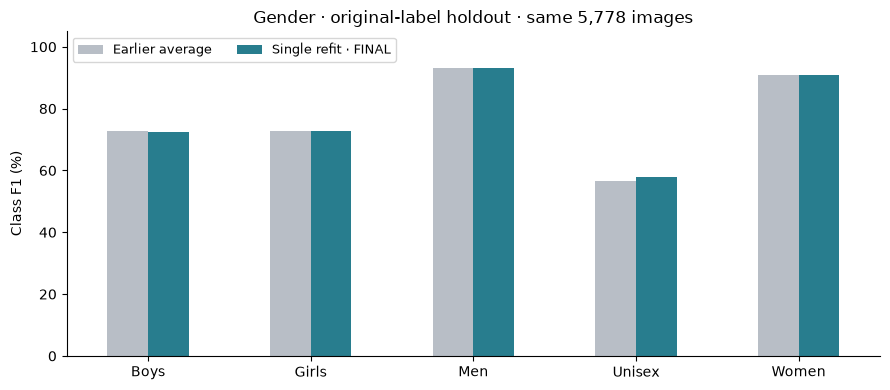

In [7]:
gender_f1 = pd.DataFrame(
    {"Earlier average": gender_class_average.f1, "Single refit · FINAL": gender_class_primary.f1}
)
fig, ax = plt.subplots(figsize=(9, 4))
gender_f1.mul(100).plot.bar(ax=ax, rot=0, color=["#b8bec6", "#287d8e"])
ax.set(
    xlabel="",
    ylabel="Class F1 (%)",
    ylim=(0, 105),
    title="Gender · original-label holdout · same 5,778 images",
)
ax.legend(title="", loc="upper left", ncol=2, fontsize=9)
fig.tight_layout()
fig.savefig(HOLDOUT_FIGURES / "gender_refit_vs_average_f1.png", dpi=150, bbox_inches="tight")
plt.show()

#### Prediction routes for each true class

Each square shows a count and the percentage of its true class. Diagonal entries are correct.


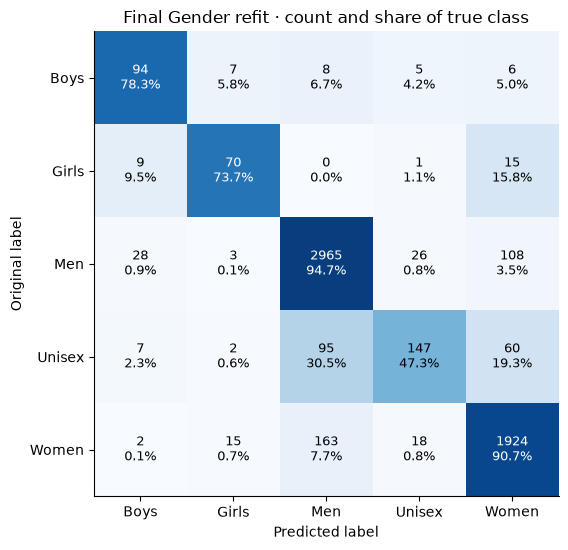

In [8]:
gender_rates = gender_cm.div(gender_cm.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(6.6, 5.6))
ax.imshow(gender_rates, cmap="Blues", vmin=0, vmax=1)
ax.set(
    xticks=range(5),
    xticklabels=gender_cm.columns,
    yticks=range(5),
    yticklabels=gender_cm.index,
    xlabel="Predicted label",
    ylabel="Original label",
    title="Final Gender refit · count and share of true class",
)
for i, j in np.ndindex(gender_cm.shape):
    ax.text(
        j,
        i,
        f"{gender_cm.iloc[i, j]}\n{gender_rates.iloc[i, j]:.1%}",
        ha="center",
        va="center",
        fontsize=9,
        color="white" if gender_rates.iloc[i, j] > 0.55 else "black",
    )
fig.tight_layout()
fig.savefig(HOLDOUT_FIGURES / "gender_holdout_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

**Unisex remains the main weakness.** The final refit finds **147 of 311** Unisex products
(47.27% recall), versus 146 for the earlier average. Its Unisex F1 rises from **56.48% to 57.87%**,
mostly because false Unisex predictions fall from 60 to 50. Precision rises from 70.87% to 74.62%,
but more than half the true Unisex products are still missed. Of those missed cases, **95 become
Men, 60 Women, seven Boys and two Girls**. This pattern is consistent with ambiguous audience
cues; it does not identify which pixel feature caused a mistake.

**The gain is not uniform.** Boys F1 falls from 72.66% to 72.31%. Girls F1 rises slightly to 72.92%,
but recall falls from 76.84% to 73.68% (73 to 70 of 95 images). Mean class recall falls from
77.24% to 76.94%, even while macro-F1 rises. Men and Women reach 93.22% and 90.86% F1;
together they supply 5,252 of 5,778 images and dominate accuracy. Boys and Girls have only
120 and 95 examples. These point estimates do not establish a reliable gain across seeds.

**Confidence and cost.** The refit's log loss is 0.2962 versus 0.2968 for the average; 15-bin
calibration error is 2.37% versus 2.35%. Both changes are tiny, and the aggregate values do not
certify confidence for a rare class. The final model has 390,181 parameters and a 1,579,253-byte
checkpoint. One forward pass replaces five; application latency was not benchmarked. Its
corruption robustness was not remeasured, so earlier fold corruption scores are not refit scores.

The refit thus preserves the practical advantage of a single model while carrying forward
the principal Gender weakness. That combination supports a modest artifact choice and a
reviewed-use recommendation, rather than a claim that audience recognition is solved.


### 10.2 Usage: earlier five-model errors

For Usage, the central issue is coverage rather than a small aggregate difference. The earlier
models show how high accuracy coexisted with complete failure on several rare labels. Their
error routes provide the reference for interpreting the later E8 refit.


,support,correct,predicted_count,precision,recall,f1
class_name,,,,,,
Casual,4441,4253,4648,0.9150,0.9577,0.9359
Ethnic,384,314,365,0.8603,0.8177,0.8385
Formal,342,252,287,0.8780,0.7368,0.8013
Home,0,0,0,0.0000,0.0000,0.0000
NA,10,0,0,0.0000,0.0000,0.0000
Party,1,0,0,0.0000,0.0000,0.0000
Smart Casual,8,0,0,0.0000,0.0000,0.0000
Sports,589,373,478,0.7803,0.6333,0.6992
Travel,3,0,0,0.0000,0.0000,0.0000


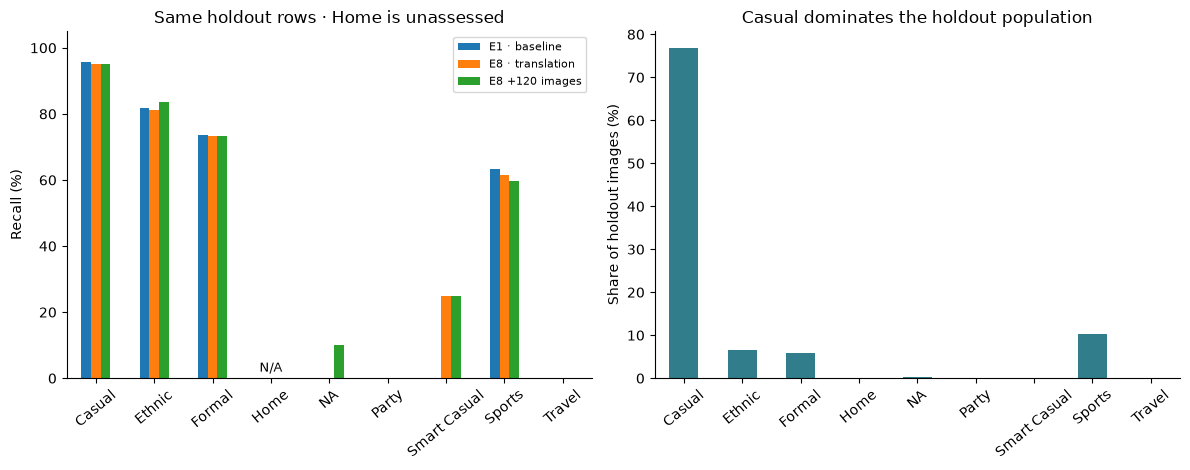

In [9]:
usage_classes = pd.read_csv(
    EVAL_ROOT / "reports/task3/usage_holdout_20260906/holdout_per_class.csv", keep_default_na=False
)

e1_classes = (
    usage_classes.loc[usage_classes.model.eq("E1")]
    .sort_values("class_index")
    .set_index("class_name")
)
display(e1_classes[["support", "correct", "predicted_count", "precision", "recall", "f1"]].round(4))
usage_recalls = (
    usage_classes.pivot(index="class_name", columns="model", values="recall")
    .reindex(e1_classes.index)
    .reindex(columns=["E1", "E8", "Expanded"])
)
usage_recalls.loc["Home"] = np.nan
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
usage_recalls.rename(columns=usage_names).mul(100).plot.bar(ax=axes[0], rot=40)
axes[0].set(
    ylabel="Recall (%)", ylim=(0, 105), xlabel="", title="Same holdout rows · Home is unassessed"
)
axes[0].annotate("N/A", (3, 2), ha="center", fontsize=9)
axes[0].legend(fontsize=8)
e1_classes.support.div(5778).mul(100).plot.bar(ax=axes[1], rot=40, color="#327d8b")
axes[1].set(
    ylabel="Share of holdout images (%)", xlabel="", title="Casual dominates the holdout population"
)
fig.tight_layout()
fig.savefig(HOLDOUT_FIGURES / "usage_holdout_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

**E1's accuracy describes common classes much better than rare ones.** Casual accounts for
4,441/5,778 images (76.86%). E1 detects 4,253 of them, with 95.77% recall. Ethnic and Formal
also perform reasonably, but Sports recall falls to 63.33%: 216 Sports items become Casual.
That is the largest off-diagonal error route in E1's Usage confusion matrix.

E1 makes no predictions for NA, Party, Smart Casual or Travel, missing all 10, one, eight and three
examples respectively. This is a clear observed failure, even though those 22 images barely affect
overall accuracy. No Home images are present, so its zero in the scoring convention is not an
observed recall failure. The eight-class diagnostic still leaves E1 at only 40.93% F1.

E8 and expanded E8 each recover two of eight Smart Casual images, but their precision is only
11.76% and 14.29%. Expanded E8 detects one of ten NA examples. All three models miss Party
and Travel. Relative to E8, expansion adds seven correct Casual, nine Ethnic and one NA prediction,
but loses 12 Sports detections. The aggregate improvement therefore hides a real trade-off between
classes. These few rare examples cannot establish reliable tagging of those occasions.

**Limits and practical use.** The holdout is separate from development at the saved family level,
and the saved results are used here for final assessment. They must not become a tuning
benchmark for future model changes. Development corruption results remain in
Notebook 4; they are not holdout robustness measurements.
Five-model averaging requires five forward passes, and no application-latency benchmark is claimed
here. The evidence supports assisted catalogue tagging with known rare-class limits, not reliable
automatic assignment of every Usage class.

### 10.3 Usage: gains and remaining errors of the accepted E8 refit

The historical models left several occasions undetected. The matched refit comparison now
shows which of those failures E8 changes and how many false predictions accompany the new
detections. Counts remain beside precision and F1 because the rare classes contain very
few evaluation images.


In [10]:
e8_classes = pd.read_csv(REFIT_HOLDOUT / "holdout_per_class.csv", keep_default_na=False)
e8_classes = e8_classes.loc[e8_classes.model.eq("Single refit")].set_index("class_name")
e1_path = EVAL_ROOT / "reports/task3/usage_e1_refit_holdout_20260907/holdout_per_class.csv"
e1_refit_classes = pd.read_csv(e1_path, keep_default_na=False)
e1_refit_classes = e1_refit_classes.loc[e1_refit_classes.model.eq("Single refit")].set_index(
    "class_name"
)
assert e8_classes.support.equals(e1_refit_classes.support)
class_comparison = e8_classes[["support", "correct", "predicted_count", "precision", "f1"]].copy()
class_comparison.insert(1, "E1 correct", e1_refit_classes.correct)
class_comparison[["precision", "f1"]] *= 100
display(
    class_comparison.rename(
        columns={
            "support": "Images",
            "correct": "E8 correct",
            "predicted_count": "E8 predictions",
            "precision": "E8 precision (%)",
            "f1": "E8 F1 (%)",
        }
    ).round(2)
)

,Images,E1 correct,E8 correct,E8 predictions,E8 precision (%),E8 F1 (%)
class_name,,,,,,
Casual,4441,4214,4199,4596,91.36,92.93
Ethnic,384,317,307,372,82.53,81.22
Formal,342,246,247,299,82.61,77.07
Home,0,0,0,0,0.00,0.00
NA,10,0,1,15,6.67,8.00
Party,1,0,0,6,0.00,0.00
Smart Casual,8,0,3,18,16.67,23.08
Sports,589,392,367,468,78.42,69.44
Travel,3,0,1,4,25.00,28.57


### Refit class performance on the same holdout

The bars use all nine class slots. Home's zero is a scoring convention; it has no examples here.


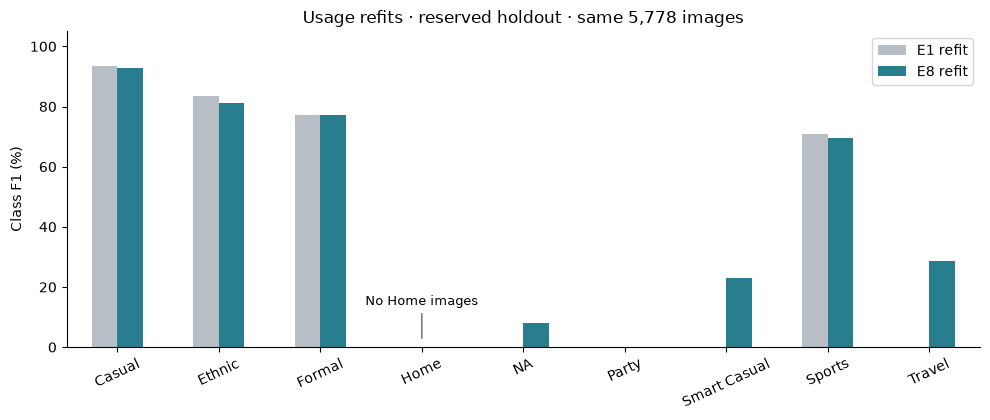

In [11]:
refit_f1 = pd.DataFrame({"E1 refit": e1_refit_classes.f1, "E8 refit": e8_classes.f1})
fig, ax = plt.subplots(figsize=(10, 4.3))
refit_f1.mul(100).plot.bar(ax=ax, rot=25, color=["#b8bec6", "#287d8e"])
ax.set(
    xlabel="",
    ylabel="Class F1 (%)",
    ylim=(0, 105),
    title="Usage refits · reserved holdout · same 5,778 images",
)
ax.annotate(
    "No Home images",
    (3, 2),
    xytext=(3, 14),
    ha="center",
    fontsize=9,
    arrowprops={"arrowstyle": "-", "color": "#666666"},
)
ax.legend(title="")
fig.tight_layout()
fig.savefig(HOLDOUT_FIGURES / "usage_refits_holdout_f1.png", dpi=150, bbox_inches="tight")
plt.show()

**Rare-class gain, with weak precision.** E1's refit misses all 22 NA, Party, Smart Casual
and Travel images. E8 gets **five right**: one of ten NA, three of eight Smart Casual and one
of three Travel. It still misses the one Party example. Only **1/15 NA**, **3/18 Smart Casual**
and **1/4 Travel** predictions are right; all six Party predictions are wrong. Home is unassessed.

Against E1's refit, E8 loses 15 correct Casual, ten Ethnic and 25 Sports images, gains one Formal
and the five rare cases, for a net loss of 44. Casual still supplies 76.86% of the holdout.
The E8 confusion matrix sends 218 Sports images to Casual, its largest error route. Equal-class
gains do not remove the common-class trade-off or ambiguous occasion boundaries.

**The gain is sensitive to very few images.** Against the old E8 average, one newly correct Travel
image contributes **3.17 of the 4.66 macro-F1 points gained**. NA adds 0.89 and Smart Casual 0.79;
the common classes lose 0.19 together. The refit fixes 90 old errors but creates 114 new ones.
This is useful observed coverage, not proof of a broad or stable gain across training seeds.

**Confidence and cost.** E8's refit has log loss 0.3173 and 15-bin calibration error 0.95%,
versus E1's 0.4308 and 6.63%. These aggregate checks do not certify rare-class confidence.
E8 has 391,209 parameters and a 1,584,821-byte checkpoint. One CPU pass with two threads and
batches of 32, including image loading and preprocessing, took 11.45 seconds. This is not a
repeated application-latency benchmark; the old average used saved probabilities, so no measured
speedup over five-model inference is claimed. Development corruption checks are not holdout
robustness tests, and the refit's darkening or translation robustness was not remeasured here.


### 10.4 Compute, storage and operating cost

The first table reads the accepted artifacts and saved training receipts. Training time is the
recorded fit time for **one final run**, excluding the earlier search, data collection and review.
Peak memory is PyTorch's allocated GPU training memory, not total device or serving memory.
Checkpoint size is disk storage, not live application RAM. These distinctions prevent a small
file from being mistaken for proof that the whole service fits on a small device.

The saved measurements therefore assess the compute implications of the proposed single-model
handoff while leaving the costs of a complete service unresolved.


In [12]:
cost_rows = []
for target, model, report in [
    ("Gender SAM25", gender_final, GENDER_HOLDOUT),
    ("Usage E8", usage_final, REFIT_HOLDOUT),
]:
    receipt = json.loads((report / "evaluation.json").read_text())
    training = receipt["training"]
    cost_rows.append(
        {
            "Model": target,
            "Parameters": model["parameter_count"],
            "Checkpoint MiB": (EVAL_ROOT / model["checkpoint"]["path"]).stat().st_size / 2**20,
            "Fit minutes": training["train_seconds"] / 60,
            "Peak allocated GPU MiB": training["peak_memory_bytes"] / 2**20,
            "Forward passes / image": model["inference"]["models"],
        }
    )
compute_cost = pd.DataFrame(cost_rows).set_index("Model")
display(compute_cost.round(2))
usage_receipt = json.loads((REFIT_HOLDOUT / "evaluation.json").read_text())
elapsed = usage_receipt["inference_seconds_including_image_preprocessing"]
image_count = usage_receipt["holdout_images"]
display(
    pd.DataFrame(
        [
            {
                "Scope": "Usage E8 only; CPU, 2 threads, batch 32; one recorded pass",
                "Images": image_count,
                "Seconds": elapsed,
                "Images / second": image_count / elapsed,
                "Amortized ms / image": elapsed / image_count * 1000,
            }
        ]
    )
    .set_index("Scope")
    .round(3)
)
print(f"Combined checkpoint storage: {compute_cost['Checkpoint MiB'].sum():.2f} MiB")
print(f"Combined recorded final-fit time: {compute_cost['Fit minutes'].sum():.2f} minutes")

,Parameters,Checkpoint MiB,Fit minutes,Peak allocated GPU MiB,Forward passes / image
Model,,,,,
Gender SAM25,390181,1.51,7.74,456.04,1
Usage E8,391209,1.51,8.81,429.23,1


,Images,Seconds,Images / second,Amortized ms / image
Scope,,,,
"Usage E8 only; CPU, 2 threads, batch 32; one recorded pass",5778,11.453,504.496,1.982


Combined checkpoint storage: 3.02 MiB
Combined recorded final-fit time: 16.55 minutes


**Interpretation.** Each accepted model needs one network pass instead of five for the old
average. That reduces the number of models to load and maintain; a fivefold speedup has not been
measured. Usage's roughly 504 images/second is batch throughput, including image loading and
preprocessing. The roughly 1.98 ms/image is an amortized value, **not single-request latency**.
There is no saved Gender timing or repeated measurement of the pair, startup, concurrent users,
network transfer, tail latency or peak serving RAM. The evidence supports a small batch-tagging
prototype; it does not prove a mobile or live-service performance target.

Financial and energy estimates require measured service use and an applicable hardware tariff.
Neither is recorded, so these costs remain unmeasured. For a given machine, compute cost is billed
hours × hourly rate; idle time and image storage also count. The next section reports observed mistakes, because the available records
do not measure the time or money needed to correct them.

### 10.5 Observed mistakes and their practical cost

Wrong tags can place products in the wrong catalogue filters or occasion suggestions.
The tables below count the actual errors on the 5,778 reserved images. The rate per 1,000
is just the observed error rate in a common unit; it is not a forecast for another shop.
Gender and Usage errors are separate label decisions, not counts of distinct products to add.

The Usage comparison separates errors on the four rare classes with holdout examples from
errors on the other classes. It shows what accepting E8 costs in correct labels. There are
no measured staff review times, labour rates or costs per mistake, so this analysis reports
no estimated hours saved or monetary saving.


In [13]:
error_workload = pd.DataFrame(
    [
        {
            "Target": "Gender SAM25",
            "Images": int(gender_cm.values.sum()),
            "Wrong": int(gender_cm.values.sum() - np.trace(gender_cm.values)),
        },
        {
            "Target": "Usage E8",
            "Images": int(e8_classes.support.sum()),
            "Wrong": int(e8_classes.support.sum() - e8_classes.correct.sum()),
        },
    ]
).set_index("Target")
error_workload["Observed errors per 1,000"] = error_workload.Wrong / error_workload.Images * 1000
display(error_workload.round(2))
rare_classes = ["NA", "Party", "Smart Casual", "Travel"]
error_rows = []
for label, classes in [("E1 refit", e1_refit_classes), ("E8 refit", e8_classes)]:
    wrong = classes.support - classes.correct
    error_rows.append(
        {
            "Model": label,
            "Other-class errors": int(wrong.drop(rare_classes).sum()),
            "Rare-class errors": int(wrong.loc[rare_classes].sum()),
            "Total errors": int(wrong.sum()),
        }
    )
display(pd.DataFrame(error_rows).set_index("Model"))

,Images,Wrong,"Observed errors per 1,000"
Target,,,
Gender SAM25,5778,578,100.03
Usage E8,5778,653,113.01


,Other-class errors,Rare-class errors,Total errors
Model,,,
E1 refit,587,22,609
E8 refit,636,17,653


**The counts expose the correction trade-off.** E1 makes 609 Usage errors and E8 makes 653.
E8 makes five fewer errors on the four rare classes and 49 more on the other classes,
for 44 additional errors overall. E8 therefore does not minimise the number of corrections.
Its selection is justified by the tested improvement in class-level performance and the
probability checks in Section 12, not by an assumed financial benefit.

Human review is the proposed response to the measured errors and weak rare precision.
It has not been measured as a source of time savings. Training duration, storage and the
recorded Usage throughput in Section 10.4 are the available measured compute costs.


### 10.6 Uncertainty in the small-class results

The error analysis showed that individual rare images account for a substantial share of the
F1 gain. The following 95% Wilson intervals quantify the uncertainty in each accepted model's
class recall under a binomial sampling model. Zero-support Home remains unassessed.

These are per-class intervals, not simultaneous guarantees. They assume independent,
representative images and do not include product-family dependence, variation across seeds
or uncertainty from the model-selection process. They describe count uncertainty rather than a confidence
interval for macro-F1.


In [14]:
recall_intervals = []
for target, classes in [("Gender", gender_class_primary), ("Usage", e8_classes)]:
    for name, row in classes.iterrows():
        count = int(row["support"])
        correct = int(gender_cm.loc[name, name]) if target == "Gender" else int(row["correct"])
        if count:
            rate, z = correct / count, 1.959963984540054
            centre = (rate + z * z / (2 * count)) / (1 + z * z / count)
            half = (
                z
                * np.sqrt(rate * (1 - rate) / count + z * z / (4 * count * count))
                / (1 + z * z / count)
            )
            lower, upper = 100 * (centre - half), 100 * (centre + half)
            estimate = 100 * rate
        else:
            estimate = lower = upper = np.nan
        recall_intervals.append([target, name, count, correct, estimate, lower, upper])
display(
    pd.DataFrame(
        recall_intervals,
        columns=[
            "Target",
            "Class",
            "Images",
            "Correct",
            "Recall (%)",
            "95% lower (%)",
            "95% upper (%)",
        ],
    )
    .set_index(["Target", "Class"])
    .round(2)
)

Images  Correct  Recall (%)  95% lower (%)  95% upper (%)
Target Class                                                                  
Gender Boys             120       94       78.33          70.15          84.76
       Girls             95       70       73.68          64.03          81.49
       Men             3130     2965       94.73          93.89          95.46
       Unisex           311      147       47.27          41.79          52.82
       Women           2122     1924       90.67          89.36          91.83
Usage  Casual          4441     4199       94.55          93.84          95.18
       Ethnic           384      307       79.95          75.66          83.65
       Formal           342      247       72.22          67.25          76.70
       Home               0        0         NaN            NaN            NaN
       NA                10        1       10.00           1.79          40.42
       Party              1        0        0.00           0.00          79.35
       Smart Casual       8        3       37.50          13.68          69.43
       Sports           589      367       62.31          58.33          66.13
       Travel             3        1       33.33           6.15          79.23

One correct Travel image out of three has a very wide interval. Party's zero out of one does
not establish zero performance in the population. The observed rare-class failures still matter,
but these tiny counts cannot prove that the refit gain will repeat. Gender's missed Unisex items
are supported by many more examples. More independent rare-class evidence is more useful here
than treating another decimal place in overall accuracy as a reliable improvement.

These intervals narrow the strength of the Usage claim: the observed detections are useful
evidence, but their population rates remain uncertain. The next step examines a further
limit, the difference between these catalogue images and more varied application inputs.


### 10.7 Robustness evidence and its limits

Notebook 4's saved development tests deliberately darken, translate and otherwise alter images.
They help explain training choices, but were used during development and are not independent
real-world validation. Neither accepted final refit has a new corruption benchmark. Clean
holdout scores therefore do not certify performance on phone photos, clutter, multiple garments,
different lighting or a new retailer's background style.

For a pilot, reject unreadable files; ask for a clearer single-product image when the input is
visibly unsuitable. This is a proposed input rule, not a measured automatic detector. Test the
frozen pair on clean and matched degraded images from the fresh audit, reporting per-class
recall loss, prediction changes and human correction time. Keep any future threshold tuning on
separate development data. Aggregate calibration errors above do not justify an automatic
confidence cutoff, especially for rare classes.

The combined evidence now supports separate judgements. Gender offers a small measured gain
with one artifact; Usage offers broader observed coverage with additional mistakes. Both
retain errors that shape the proposed level of human review.


## 11. Gender — Ultimate judgement

**We select the single full-development SAM25 refit at epoch 25.** This conclusion follows
two linked comparisons. Development established a fixed recipe after the label and
regularisation study; the saved holdout comparison then supported replacing the earlier
five-model average with one refitted model.

**The development results established the recipe.** On the matched corrected-label screen, MixUp alone scored
80.89% macro-F1 with a 12.91-point clean training–validation gap. SAM30 reduced the gap
to 10.86 points but lost five Unisex detections. The separately fixed SAM25 run
restored those detections to 361 of 707 and achieved 79.86% macro-F1 with a 9.93-point gap.

We accepted the 1.03-point screen F1 loss against MixUp for a 2.98-point smaller gap,
unchanged Unisex detection count, and better F1 than SAM30 (79.86% versus 79.43%).
These measured changes justified advancing SAM25 to the five-fold evaluation; they do not prove that a smaller gap
always means a better model. MixUp still had the higher screen F1 and 53 fewer errors.
The next five-fold evaluation matters: SAM25 reached 79.73% pooled F1, with fold scores
from 78.60% to 80.83%; the additional folds 1–3 reached 79.63%. This supports retaining
the fixed recipe beyond its initial two-fold screen. It does not establish an untested
five-fold or final-holdout win over MixUp alone.

**The holdout comparison supported the single refit.** On the same 5,778 reserved images and original labels,
the refit achieved **90.00% accuracy and 77.44% macro-F1**, against the earlier average's
**89.82% and 77.14%**. It corrected 65 of the average's errors and introduced 55,
leaving **ten more correct predictions overall**. It also uses one checkpoint and one
network pass per image instead of five. These observed results justify choosing the
simpler single artifact: its lower model count did not require sacrificing either main
aggregate score on the completed comparison. They do not establish a measured fivefold speedup.

**The class regressions limit that choice.** Unisex recall is still 47.27%. Boys F1 falls slightly,
and Girls recall falls from 76.84% to 73.68%. Average class recall also falls, despite the
small macro-F1 gain. Calibration error changes from 2.35% to 2.37%, so improved confidence
is not a reason for this selection. We judge the small aggregate gains and simpler artifact
sufficient to accept the refit, while retaining these class regressions in the judgement.
One seed and small measured differences limit claims that the advantage will repeat.

**Cost and practical use.** The recorded fit took 7.74 minutes, with 456.04 MiB of allocated
GPU training memory and a 1.51 MiB checkpoint. No Gender serving latency or human time saving
was measured. The model made 578 holdout errors, including 164 missed Unisex products.
Those errors justify keeping human review for catalogue suggestions. The selected model
predicts product audience tags; it does not establish a person's identity or an exclusive
audience for an item. **SAM25 is the final Gender artifact, with reviewed suggestions as
the proposed application rather than a claim of proven automatic tagging.**


### 11.1 Final Gender model and prediction process

**Selected model: SmallCNN with GeM pooling, trained with MixUp and SAM for 25 epochs.**
An epoch is one pass through the training data. This model learned from scratch on all
32,773 development images. It has 390,181 learned numbers, called parameters, which control
how image patterns contribute to its decisions.

**From photo to label.** The photo is resized to 80 pixels high and 60 pixels wide while
keeping its shape. Padding fills the remaining space. Its red, green and blue values are
adjusted using statistics saved from the development images.

Four layers of small 3×3 filters look for visual patterns. They produce 32, 64, 128 and then
256 pattern maps. Each layer rescales its values and keeps positive responses; after the first
three layers, each 2×2 area is reduced to its strongest response. This makes the maps smaller
while retaining strong evidence.

GeM pooling then turns each final map into one number. Here its power is fixed at 3:
cube the positive responses, take their average, then take the cube root. This gives strong
responses more influence than a plain average. The resulting 256 numbers feed a final layer
that gives one score for each of Boys, Girls, Men, Unisex and Women.

For each class, that score is a **weighted sum of the 256 features, plus a learned offset**.
Softmax turns the five scores into probabilities that sum to one. The model returns the class
with the largest probability. These probabilities are model estimates, not guarantees.

**Training shaped this prediction rule.** MixUp blends two training photos and their labels. Its setting,
alpha 0.20, controls the random blend proportions. The training penalty combines the errors
against both labels in those same proportions. Cross-entropy is the error measure: it gives
a larger penalty when the model assigns a low probability to the correct label.
Gender does not give extra loss weight to particular classes.

SAM, with a neighbourhood size of 0.05, checks whether a small change to the model's weights
makes that penalty worse, then uses the result to guide the update. AdamW performs the weight
updates. Dropout hides 30% of the final features during training to reduce reliance on a few
features. Blending, SAM updates and dropout stop when the model makes predictions.

**The saved checkpoint completes the prediction process.** The complete learned weights and saved layer statistics come from
one file: the final epoch-25 checkpoint printed below. A checkpoint is a saved model.
It supplies **100% of the prediction**; the earlier five-model average is not used.
The displayed SHA-256 value is a file fingerprint that identifies the exact saved weights.
The code also reads the saved colour-adjustment values and class order, so these details
can be reproduced without copying thousands of learned numbers into the report.


In [15]:
selected = gender_final
print("Gender accepted run:", selected["run_id"])
print("Full learned weight file:", selected["checkpoint"]["path"])
print("SHA-256:", selected["checkpoint"]["sha256"])
print("Saved configuration:", selected["config"]["path"])
print("Saved preprocessing:", selected["normalization"]["path"])
print("Prediction model weight: 1.0 (single checkpoint)")
print("Output class order:", ", ".join(selected["class_names"]))
normalization = json.loads((EVAL_ROOT / selected["normalization"]["path"]).read_text())
display(
    pd.DataFrame(
        {"Channel": list("RGB"), "Mean": normalization["mean"], "Std": normalization["std"]}
    )
    .set_index("Channel")
    .round(9)
)

Gender accepted run: t3_gender_name_truth_mixup_alpha020_sam005_epoch25_refit_20260907T061926Z_db0fc1ee
Full learned weight file: results/evidence/task3/gender_sam25_refit_20260907/final_epoch.pt
SHA-256: 41a5f5ea027805e8edbbf667d080564776ca9873d9146e0dec15c0d4bec2b272
Saved configuration: results/evidence/task3/gender_sam25_refit_20260907/config.json
Saved preprocessing: results/evidence/task3/gender_sam25_refit_20260907/normalization.json
Prediction model weight: 1.0 (single checkpoint)
Output class order: Boys, Girls, Men, Unisex, Women


,Mean,Std
Channel,,
R,0.849999,0.271111
G,0.833254,0.282661
B,0.827607,0.286203


## 12. Usage — Ultimate judgement

**The selected Usage model is the single teacher-only E8 refit at epoch 30.** Its development
rationale is the trade-off documented in Section 18 of the development notebook: observed
class coverage, shift tolerance and probability quality justify accepting lower accuracy,
worse dark-image performance and an uncertain clean lead over E2/E3. This section assesses
that retained model on the saved holdout; it does not use the holdout to propose a new recipe
or choose another checkpoint. The development rationale and final assessment serve
different purposes and retain their own evidence.

**The development comparison supports the recipe.** On the same five development folds,
E8 achieved 41.94% macro-F1 against E1's 37.38%, while accuracy fell from 89.30% to 88.85%.
That is a 4.56-point macro-F1 gain for a 0.45-point accuracy loss. The tested data expansions
and later regularisation trials did not establish a stronger teacher-data macro-F1 alternative.
Against E2, translation reduced the mean fold shift loss from 8.69 to 2.69 F1 points and
calibration error from 3.31% to 0.79%, while darkening loss worsened from 12.89 to 16.19 points.
The family-bootstrap clean-score interval against E2 crosses zero; against E3 it spans
−2.39 to +3.18 points. The choice accepts those limits rather than claiming that the original
improvement gates passed. The fixed refit uses all eligible development rows; the fold
scores and robustness measurements are not scores for its new weights.

The full development path also covers E3–E9, S1/S2, U1/U2/U3, probability
diagnostics and expanded-data follow-ups. E5 retains a lighting advantage, E6 a
slight NLL advantage, and the three-model average a higher clean F1 (42.31%).
That average was not advanced to matched corruption tests and final refits.
The single E8 choice accepts these alternatives' strengths; it is not a universal win.

**The completed refit test assesses the retained trade-off.** On the same 5,778 reserved
images, E8 achieved **42.26% macro-F1 and 88.70% accuracy**, compared with E1's
**36.09% and 89.46%**. E8 gained **6.17 macro-F1 points** at the cost of **44 additional
wrong predictions**, or **0.76 accuracy points**. The direction of the trade-off agrees
with the development comparison. Macro-F1 and accuracy measure different things, so their
point changes are not an exchange rate; the class results show the practical effect of the loss.

**The class counts explain the observed loss.** Casual makes up 76.86% of the holdout, so overall accuracy
can remain high while a model misses whole Usage classes. E1 missed all 22 examples of NA,
Party, Smart Casual and Travel. E8 correctly identified five: one NA, three Smart Casual and
one Travel. It retained 94.55% Casual recall, compared with E1's 94.89%, while expanding
observed coverage beyond the dominant classes. This is not a free gain: E8 also lost ten
correct Ethnic and 25 correct Sports predictions, while gaining one Formal prediction.
For a task that must predict all nine labels, the result shows some wider class coverage
alongside a real cost in total correct predictions. It supports a limited use with human
review; E1 remains better at minimising the total number of errors on this evaluation.

**Supporting evidence and limits.** E8's log loss was 0.3173 versus E1's 0.4308, and its
15-bin calibration error was 0.95% versus 6.63%. These checks also favour E8's probability
outputs overall. They do not make its rare predictions reliable: rare-class precision remains
low, Party is still missed, and Home has no evaluation examples. The gain depends partly on
very few images, and the refits use one seed. The comparison measures these saved models
on this teacher population, not stability across training runs or other catalogues.
These limits narrow the intended use and prevent a claim of reliable automatic tagging.

**Cost and practical decision.** The final fit took 8.81 minutes and used 429.23 MiB of
allocated GPU training memory. Its checkpoint is 1.51 MiB. The recorded CPU batch pass
processed about 504 images/second, although single-request latency was not measured.
These measurements establish modest storage and recorded batch compute costs; they
do not measure staff productivity or performance of a complete application. Staff should review every suggestion, including Casual, because missed
Sports and rare items can appear under common labels.

The observed error counts in Section 10.5 show that E1 needs fewer corrections.
No financial saving has been measured for E8. The development trade-off explains the retained
recipe; this evaluation shows its practical gains and limits. **E8 is the final Usage model for reviewed
catalogue suggestions; the evidence does not support automatic publication of every tag.**

The remaining errors motivate the development proposals in Section 15. Those proposals do not
change the accepted E8 checkpoint or establish a new performance claim.


### 12.1 Final Usage model and prediction process

**Selected model: SmallCNN E8 with average pooling and a class-weighted training loss,
trained for 30 epochs.** It learned from scratch on all 32,772 eligible teacher development
images. Its 391,209 learned parameters control how image patterns contribute to nine
possible Usage labels.

**From photo to label.** The photo is resized to 80 pixels high and 60 pixels wide while
keeping its shape, then padded. Its colours are adjusted using this Usage model's own saved
development statistics.

Four layers of 3×3 filters produce 32, 64, 128 and then 256 pattern maps. Each layer rescales
its values and keeps positive responses. After the first three layers, each 2×2 area is
reduced to its strongest response. Average pooling then takes the average value of each
final map, leaving 256 numbers that summarise the photo.

For each Usage class, the final layer calculates a **weighted sum of those 256 numbers,
plus a learned offset**. Softmax turns the nine scores into probabilities that sum to one.
The model chooses the largest: Casual, Ethnic, Formal, Home, NA, Party, Smart Casual,
Sports or Travel. NA means the occasion label is unknown. A high probability alone does
not prove that a rare-class prediction is reliable.

**Class weights connect the model to the observed imbalance.** Casual has far more training images than the rare
classes. Giving every image the same penalty can let Casual dominate learning. E8 therefore
gives errors on rare classes more weight. These training weights are different from the
thousands of learned weights inside the network.

The effective-number rule calculates each class weight from its image count. With beta set
to 0.999, the starting value is **(1 − beta) divided by (1 − beta raised to the class count)**.
The values are divided by their average across classes that are present, then capped at 5.
They are not rescaled after the cap. The table below shows all nine saved weights and the
counts used to calculate them.

Cross-entropy penalises low probability for the correct label. For a training batch, E8
multiplies each image's penalty by its class weight, adds the penalties, and divides by
the sum of those weights. Half the training images are also randomly shifted by up to two
pixels to reduce reliance on exact placement. There is no classifier dropout.

**The saved checkpoint supplies the prediction weights.** One final epoch-30 checkpoint supplies
**100% of the prediction**. Its complete learned weights and saved layer statistics are in
the file printed below. The SHA-256 fingerprint identifies that exact file. The class-loss
weights are not multiplied into prediction probabilities; they have already influenced
what the model learned. No random shifts, averaging of models or confidence cutoff are
applied when producing the predicted class.


In [16]:
selected = usage_final
print("Usage accepted run:", selected["run_id"])
print("Full learned weight file:", selected["checkpoint"]["path"])
print("SHA-256:", selected["checkpoint"]["sha256"])
print("Saved configuration:", selected["config"]["path"])
print("Saved preprocessing:", selected["normalization"]["path"])
print("Prediction model weight: 1.0 (single checkpoint)")
print("Output class order:", ", ".join(selected["class_names"]))
normalization = json.loads((EVAL_ROOT / selected["normalization"]["path"]).read_text())
display(
    pd.DataFrame(
        {"Channel": list("RGB"), "Mean": normalization["mean"], "Std": normalization["std"]}
    )
    .set_index("Channel")
    .round(9)
)
usage_config = json.loads((EVAL_ROOT / selected["config"]["path"]).read_text())
class_weight_contract = usage_config["class_weight_contract"]
display(
    pd.DataFrame(
        {
            "Class": class_weight_contract["class_names"],
            "Development images": class_weight_contract["class_counts"],
            "Training loss weight": class_weight_contract["class_weights"],
        }
    )
    .set_index("Class")
    .style.set_uuid("usage-final-class-weights")
    .format({"Training loss weight": "{:.17g}"})
)

Usage accepted run: t3_usage_e8_translation_teacher_all_development_refit_5553be0c138243e9
Full learned weight file: results/evidence/task3/usage_e8_refit_20260907/final_epoch.pt
SHA-256: 18da75a4ec935ab0d18c9ebdf9d1dabb6fa87ee484ead5f439de0192c4af2747
Saved configuration: results/evidence/task3/usage_e8_refit_20260907/config.json
Saved preprocessing: results/evidence/task3/usage_e8_refit_20260907/normalization.json
Prediction model weight: 1.0 (single checkpoint)
Output class order: Casual, Ethnic, Formal, Home, NA, Party, Smart Casual, Sports, Travel


,Mean,Std
Channel,,
R,0.849998,0.271110
G,0.833253,0.282661
B,0.827605,0.286203


,Development images,Training loss weight
Class,,
Casual,25151,0.0076744943301350855
Ethnic,2183,0.0086480959725365892
Formal,1949,0.008947527071396906
Home,1,5
NA,61,0.12962474255306328
Party,12,0.64306629573224505
Smart Casual,47,0.16707277576657217
Sports,3346,0.0079542125768153199
Travel,22,0.35251752595265501


## 13. Official predictions and system handoff

**Usage handoff is frozen:** use the single E8 checkpoint and saved preprocessing displayed below.
The teacher did not supply test labels, so official prediction images are used only to produce
predictions. No test scores are included in the report. The complete output must retain
`id,gender,articleType,season,usage`; the other targets and the full team submission still need to be completed.

**Gender handoff is frozen:** use the single SAM25 checkpoint and saved normalization displayed below.
Do not use the historical five-fold average or assign its old test predictions to this refit.
The refit has not produced an official test prediction file in this update. The test set remains
prediction-only; the full four-target submission and its checks remain pending.

The handoff translates the preceding judgements into specific prediction artifacts. Their
identities and preprocessing are reproduced below so that the proposed application uses
the same models whose evidence was assessed.


In [17]:
model_rows, normalization_rows = [], []
for target, model in [("Gender", gender_final), ("Usage", usage_final)]:
    config = json.loads((EVAL_ROOT / model["config"]["path"]).read_text())
    normalization = json.loads((EVAL_ROOT / model["normalization"]["path"]).read_text())
    model_rows.append(
        [
            target,
            model["training_rows"],
            model["selected_epoch"],
            model["parameter_count"],
            config["seed"],
            config["batch_size"],
            config["learning_rate"],
            config["weight_decay"],
            model["accepted_on"],
        ]
    )
    for channel, mean, std in zip("RGB", normalization["mean"], normalization["std"]):
        normalization_rows.append([target, channel, mean, std])
    print(f"{target}: {model['run_id']}")
    print("Checkpoint:", model["checkpoint"]["path"])
    print("SHA-256:", model["checkpoint"]["sha256"])
    print("Class order:", ", ".join(model["class_names"]))
display(
    pd.DataFrame(
        model_rows,
        columns=[
            "Target",
            "Training images",
            "Epochs",
            "Parameters",
            "Seed",
            "Batch",
            "Learning rate",
            "Weight decay",
            "Accepted on",
        ],
    ).set_index("Target")
)
display(
    pd.DataFrame(normalization_rows, columns=["Target", "Channel", "Mean", "Std"])
    .set_index(["Target", "Channel"])
    .round(6)
)

Gender: t3_gender_name_truth_mixup_alpha020_sam005_epoch25_refit_20260907T061926Z_db0fc1ee
Checkpoint: results/evidence/task3/gender_sam25_refit_20260907/final_epoch.pt
SHA-256: 41a5f5ea027805e8edbbf667d080564776ca9873d9146e0dec15c0d4bec2b272
Class order: Boys, Girls, Men, Unisex, Women
Usage: t3_usage_e8_translation_teacher_all_development_refit_5553be0c138243e9
Checkpoint: results/evidence/task3/usage_e8_refit_20260907/final_epoch.pt
SHA-256: 18da75a4ec935ab0d18c9ebdf9d1dabb6fa87ee484ead5f439de0192c4af2747
Class order: Casual, Ethnic, Formal, Home, NA, Party, Smart Casual, Sports, Travel


,Training images,Epochs,Parameters,Seed,Batch,Learning rate,Weight decay,Accepted on
Target,,,,,,,,
Gender,32773,25,390181,2753,128,0.001,0.0001,2026-09-07
Usage,32772,30,391209,2753,128,0.001,0.0001,2026-09-07


Mean       Std
Target Channel                    
Gender R        0.849999  0.271111
       G        0.833254  0.282661
       B        0.827607  0.286203
Usage  R        0.849998  0.271110
       G        0.833253  0.282661
       B        0.827605  0.286203

### 13.1 Shared application workflow

**Use case: a staff member adds a product to a shop catalogue.** They upload one product photo.
The service applies the saved resize, padding and each model's own normalization, runs the two
accepted checkpoints in evaluation mode, and turns output indices into the saved class names.
The interface shows Gender and Usage as editable suggestions beside the photo. Staff check
both against product text, correct or leave a tag unset, then approve publication. Store the
model version, suggestion and approved tag so later corrections can be audited. A failed model
request leaves the manual form available. This describes the integration contract; the notebook
does not claim an implemented or tested GUI.

**Practical recommendation: review every suggestion.** No confidence-based auto-publish threshold has
been validated. Before reducing review, agree with the shop on acceptable class-specific error
costs, time savings and response-time limits; lock those targets before the new audit. Measure
correction rate and task time against manual entry, and repeated latency and serving memory on
the intended machine. An additional application audit should include rare and unseen-style products,
because these are not adequately covered by the present evidence. Release broader automation only if those pre-agreed limits are met, including uncertainty.

During a pilot, inspect an ongoing independently labelled sample for class errors and shifts in
image style, track staff corrections and response failures, and return to manual tagging if the
agreed limits fail. Collect corrections for a later development set; do not silently retrain the
frozen models. **The present judgement is limited viability for assisted catalogue tagging;
fully automatic tagging and generalisation to new shops remain unproven.**

## 14. Literature review: interpreting the remaining failures

The completed evaluation leaves five connected concerns: uncertain reference labels, reliance
on catalogue cues, weak rare-class precision, poor transfer between photo sources, and repeated
model selection. The following papers help interpret those concerns. Their methods were not
reproduced here, and their published gains are not direct benchmarks for these scratch models.

### 14.1 Label ambiguity and human disagreement

Peterson et al. [1] collected distributions of human judgements for CIFAR10H and trained models
with these image-specific soft labels. Their experiments found improved generalisation and
robustness. Unlike uniform label smoothing, this approach records which alternative labels
people actually consider plausible for each image.

Our Gender name-rule review changed the scoring basis, but Unisex remained difficult. Usage
also contains overlapping occasion labels. These observations make annotation agreement relevant;
they do not establish how often people would disagree. A product-name correction is not a human
uncertainty distribution. The paper supports examining label meaning before attributing all
remaining error to the network, without proving that soft-label training would help this dataset.

### 14.2 Catalogue cues and the final decision layer

Kirichenko et al. [2] show that a representation can contain useful features even when the final
classifier relies on spurious correlations. Their Deep Feature Reweighting method freezes the
representation and retrains its last layer on data balanced across shortcut groups.

This offers a possible explanation for our strong training fit alongside weak held-family
performance: useful features might exist but receive insufficient weight in the final decision.
The ArticleType–Usage association makes that hypothesis relevant. It remains unproven here.
Balancing the nine classes alone does not reproduce group balancing, and our small scratch
networks may lack the needed features. This limits how directly the paper's results transfer.

### 14.3 Class balance, coverage and false alarms

Hong et al. [3] treat long-tailed recognition as a label-shift problem and propose LADE to
separate training class frequencies from predictions. Their formulation allows the target
population to remain imbalanced rather than assuming that all classes occur equally often.

This matters for our Usage judgement. Weighting improved equal-class F1, but rare predictions
still had low precision and added mistakes on common classes. A catalogue dominated by Casual
requires both coverage and false-alarm counts. Macro-F1 is not equivalent to accuracy on a
balanced population. The paper helps frame that trade-off; it does not prove that a prior
correction would solve our errors. Added-source images change visual content as well as class
counts, so a label-shift explanation alone is insufficient.

### 14.4 Transfer between photo sources

Gulrajani and Lopez-Paz [4] compare domain-generalisation methods under consistent conditions
in DomainBed. They show that the model-selection rule is part of the method, and that a
carefully implemented ordinary training baseline can compete with specialised methods.

Our expanded Usage model recognised 125/127 new-source Party images and 147/156 new-source
Smart Casual images, but none of the 12 and 47 corresponding teacher development images.
That contrast makes source-specific results more informative than a high mixed-source score.
The paper supports controlling sources and selection rules. It does not identify which
background, product or label difference caused our failure. Our teacher/outside mixture is
not a reproduction of DomainBed or a test of general performance on new shops.

### 14.5 Overfitting the experiment-selection process

Cawley and Talbot [5] show that optimising a noisy model-selection criterion can overfit that
criterion and bias performance estimates. This can happen even when each model respects its
training split. It is distinct from a large training–validation gap within one run.

We repeatedly consulted development folds when choosing architectures, augmentations, label
rules and training budgets. Five-fold confirmation and
family resampling describe the saved comparisons, but do not remove the effect of that search.
The paper therefore supports reporting observed trade-offs without treating small leads as
unbiased estimates of future superiority. It gives no numerical correction for this project's
selection bias. These limits shape the process improvements below.


## 15. Future improvements to the process and results

The next cycle should start with label and data checks, then test a small number of targeted
model changes. Another architecture run is useful only if those checks identify a problem it
can address. The proposals below preserve the accepted models and treat improvement as a
hypothesis to test, not an outcome already achieved.

### 15.1 Clarify the labels before trying to fit them more closely

Following the uncertainty perspective in [1], select a development sample containing common
classes, Unisex, and the rare Usage classes. Ask several reviewers to label the same images
independently without seeing predictions. Record disagreement and whether an image alone supplies
enough information. Review product text separately so that missing visual information can be
distinguished from unclear category rules.

Use this audit to write clearer labelling guidance and identify classes needing more evidence.
Keep original labels and any reviewed variant separate. Agreement makes the review target more
consistent; it does not guarantee visual learnability. Only after this audit should a separate
development experiment compare ordinary targets with reviewer-derived soft targets. Judge it
using per-class errors and calibration on a fixed label basis, rather than crediting a changed
scoring rule as a learned gain.

### 15.2 Collect examples that fill measured gaps

The source-transfer failure and [4] support collecting independent product families that match
the missing teacher categories, rather than increasing image count alone. Record retailer,
product type, photo style and label evidence. Audit overlaps with existing families before
admission. Teacher-style Smart Casual watches and varied Party products are examples of gaps
to inspect, not labels to assign from appearance alone.

Make one controlled development comparison using the same recipe and saved teacher folds, with
an explicitly versioned intake and family assignments. Retain all original teacher rows and
their folds. Report teacher-only, added-source and per-class results separately. A useful
addition must improve the intended teacher classes without unacceptable common-class losses;
high recall on the added source alone does not pass that test. Set those limits before the run.

### 15.3 Test the decision layer before replacing the backbone

The mechanism in [2] motivates a group-aware classifier experiment. First check whether the
teacher development data contain enough independent families that break the suspected
ArticleType–Usage association. Within each saved training complement, reserve supported families
for reweighting and exclude them from scratch feature learning. Freeze the features, then compare
a group-balanced final-layer fit with a matched ordinary final-layer fit on the same reserved
families. This isolates the balancing rule; the original recipe remains a separate benchmark.

Use the outer validation fold only to evaluate the declared candidates. Report group recall,
rare-class precision, macro-F1 and Casual/Sports errors. Tune any settings only inside the training
complement. If the required groups lack support, stop this test and address that data gap first.
If classifier retraining fails, that result does not by itself prove that no useful features exist.

### 15.4 Make the rare-class trade-off an explicit test

Drawing on [3], compare the current weighted loss with one prior-aware alternative as a separate
experiment. Keep architecture, data version, folds and training budget fixed. Estimate priors
from permitted training data; do not fit a correction to the reviewed holdout. Visual source
differences may violate a pure label-shift assumption, so this is a limited test of class-frequency
effects, not a proposed cure for all transfer problems.

Set acceptable rare-class false alarms and common-class losses before looking at results.
Report precision, recall and counts alongside macro-F1 and total errors. Retain a candidate only
if its coverage gain meets those limits. A smaller training gap or higher aggregate F1 alone
cannot establish that catalogue suggestions have become more useful.

### 15.5 Reduce selection bias and verify the final use case

Following [5], predeclare the candidates, primary metric, acceptance limits and run budget.
Use the existing saved folds for development, with matched seeds across candidates, and report
failed trials as well as successes. Repeat the small set of finalists across seeds to measure
training variation. This improves the evidence but does not make already consulted folds fresh.

After selection, freeze the models and audit protocol. In line with [4], use a newly collected,
independently labelled catalogue from a source absent from development, with no family overlaps.
Keep a rare-class audit separate from a sample at natural shop frequencies. Report counts and
uncertainty, including unassessed classes. Score once; if the results prompt changes, they become
development evidence and another fresh audit is needed. Do not use the reviewed holdout to tune
any of these proposals.

Finally, test the reviewed-tagging workflow against manual entry. Measure correction rate,
review time, repeated response latency and serving memory on the intended machine. Predeclare
acceptable error and service limits. These checks would establish whether a better model score
also improves the actual process; neither that benefit nor new external-validation results are
claimed by the present study.


## 16. References

[1] J. C. Peterson, R. M. Battleday, T. L. Griffiths, and O. Russakovsky, “Human uncertainty
makes classification more robust,” in *Proc. IEEE/CVF International Conference on Computer
Vision (ICCV)*, 2019, pp. 9617–9626. arXiv:1908.07086.

[2] P. Kirichenko, P. Izmailov, and A. G. Wilson, “Last layer re-training is sufficient for
robustness to spurious correlations,” in *Proc. International Conference on Learning
Representations (ICLR)*, 2023. arXiv:2204.02937.

[3] Y. Hong, S. Han, K. Choi, S. Seo, B. Kim, and B. Chang, “Disentangling label distribution
for long-tailed visual recognition,” in *Proc. IEEE/CVF Conference on Computer Vision and
Pattern Recognition (CVPR)*, 2021, pp. 6626–6636. arXiv:2012.00321.

[4] I. Gulrajani and D. Lopez-Paz, “In search of lost domain generalization,” in *Proc.
International Conference on Learning Representations (ICLR)*, 2021. arXiv:2007.01434.

[5] G. C. Cawley and N. L. C. Talbot, “On over-fitting in model selection and subsequent
selection bias in performance evaluation,” *Journal of Machine Learning Research*, vol. 11,
pp. 2079–2107, 2010.
